In [1]:
# ---- SETUP: load data, train model, predict xG for every shot ----
import pandas as pd                                      # data tables
import numpy as np                                       # math
import sqlite3                                           # database access
import matplotlib.pyplot as plt                          # charts
from sklearn.linear_model import LogisticRegression      # our model

# Load the La Liga features we saved in Phase 2
conn = sqlite3.connect(r'C:\Users\User\Desktop\football-xg-model\data\football_xg.db')
df = pd.read_sql("SELECT * FROM shot_features", conn)    # all 9168 shots

# Set up features (X) and target (y)
X = df[['distance', 'angle', 'is_header', 'is_penalty', 'is_open_play']]
y = df['goal']

# Train the model on ALL the data this time.
# (For player analysis we want an xG value for every shot, so we train on everything.)
model = LogisticRegression(max_iter=1000)   # create the model
model.fit(X, y)                             # train on all shots

# Predict xG for every single shot and add it as a new column called 'our_xg'
# [:, 1] grabs the probability of a goal for each shot
df['our_xg'] = model.predict_proba(X)[:, 1]

# Confirm it worked
print("xG predicted for all", df.shape[0], "shots")
df[['player', 'our_xg', 'goal']].head()

xG predicted for all 9168 shots


,player,our_xg,goal
0,Jonathan Rodríguez Menéndez,0.063141,0
1,Gareth Frank Bale,0.222840,1
2,Cristiano Ronaldo dos Santos Aveiro,0.082606,1
3,Luka Modrić,0.017770,0
4,Karim Benzema,0.248772,1


In [2]:
# ---- Build a player summary: actual goals vs expected goals (xG) ----

# Group all shots by player, then for each player calculate:
#   shots     = how many shots they took (count of rows)
#   goals     = how many actually went in (sum of the 'goal' column)
#   xg        = their total expected goals (sum of our_xg — the chances they got)
# .agg() lets us do several calculations at once.
player_stats = df.groupby('player').agg(
    shots=('goal', 'count'),      # count how many shots each player took
    goals=('goal', 'sum'),        # sum of goals (each goal = 1)
    xg=('our_xg', 'sum')          # sum of xG = total quality of chances they got
).reset_index()                   # turn the grouped result back into a normal table

# The key number: goals minus xG.
# POSITIVE = scored MORE than expected (clinical finisher / lucky)
# NEGATIVE = scored FEWER than expected (wasteful / unlucky)
player_stats['goals_minus_xg'] = player_stats['goals'] - player_stats['xg']

# Round xG and the difference to 2 decimals so it's readable
player_stats['xg'] = player_stats['xg'].round(2)
player_stats['goals_minus_xg'] = player_stats['goals_minus_xg'].round(2)

# Only keep players who took enough shots to be meaningful (at least 20).
# A player with 3 shots isn't a reliable sample — this avoids noise.
player_stats = player_stats[player_stats['shots'] >= 20]

# Show how many players are left after filtering
print("Players with 20+ shots:", player_stats.shape[0])

Players with 20+ shots: 151


In [3]:
# ---- TOP OVER-PERFORMERS: scored the most ABOVE their xG ----
# Sort players by goals_minus_xg, highest first.
# These are the clinical finishers — they scored more than their chances "should" have yielded.
top_overperformers = player_stats.sort_values('goals_minus_xg', ascending=False).head(10)

# Show the key columns
print("TOP 10 OVER-PERFORMERS (clinical finishers):")
print(top_overperformers[['player', 'shots', 'goals', 'xg', 'goals_minus_xg']].to_string(index=False))

TOP 10 OVER-PERFORMERS (clinical finishers):
                             player  shots  goals    xg  goals_minus_xg
           Luis Alberto Suárez Díaz    139     40 25.79           14.21
                  Gareth Frank Bale     81     19  8.03           10.97
                  Antoine Griezmann     92     22 13.55            8.45
Cristiano Ronaldo dos Santos Aveiro    228     35 28.50            6.50
                      Karim Benzema     98     24 18.23            5.77
            Imanol Agirretxe Arruti     45     13  7.90            5.10
               Lucas Pérez Martínez     98     17 12.31            4.69
               Jozabed Sánchez Ruiz     45      9  4.35            4.65
                Rubén Castro Martín    103     19 14.53            4.47
             Iñaki Williams Arthuer     45      8  3.80            4.20


In [4]:
# ---- TOP UNDER-PERFORMERS: scored the most BELOW their xG ----
# Sort ascending, so the most negative (biggest shortfall) comes first.
# These players got good chances but converted fewer than expected (wasteful or unlucky).
top_underperformers = player_stats.sort_values('goals_minus_xg', ascending=True).head(10)

print("TOP 10 UNDER-PERFORMERS (wasteful / unlucky):")
print(top_underperformers[['player', 'shots', 'goals', 'xg', 'goals_minus_xg']].to_string(index=False))

TOP 10 UNDER-PERFORMERS (wasteful / unlucky):
                     player  shots  goals   xg  goals_minus_xg
      Álvaro Vázquez García     48      5 8.49           -3.49
   Diego Roberto Godín Leal     26      1 4.18           -3.18
Carlos Alberto Vela Garrido     61      5 7.78           -2.78
        Grzegorz Krychowiak     22      0 2.76           -2.76
    Marco Asensio Willemsen     59      4 6.58           -2.58
             Nordin Amrabat     28      0 2.56           -2.56
       Jorge Andújar Moreno     32      1 3.52           -2.52
             Luciano Vietto     25      1 3.48           -2.48
       Roger Martí Salvador     21      0 2.48           -2.48
     Rodrigo Moreno Machado     38      2 4.43           -2.43


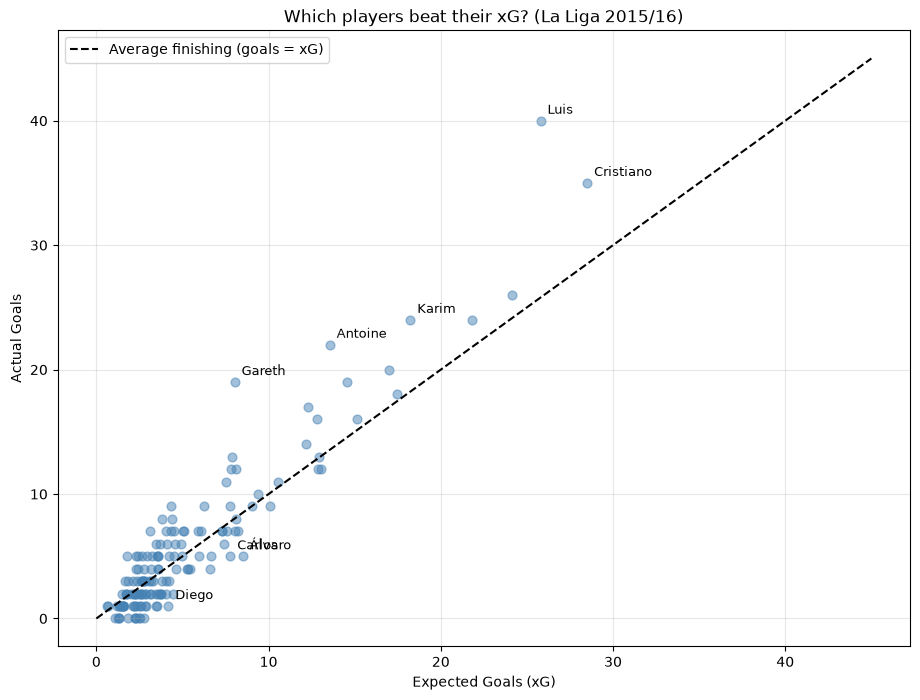

In [5]:
# ---- SCATTER: expected goals (xG) vs actual goals, per player ----
plt.figure(figsize=(11, 8))                              # nice big figure

# Plot every qualifying player as a dot: their total xG (x-axis) vs actual goals (y-axis)
plt.scatter(player_stats['xg'], player_stats['goals'],
            alpha=0.5, s=40, color='steelblue')          # semi-transparent blue dots

# Draw the "average finishing" diagonal line (goals = xG).
# Players ABOVE this line scored more than expected; BELOW scored fewer.
max_val = player_stats['goals'].max() + 5                # figure out how long to draw the line
plt.plot([0, max_val], [0, max_val], 'k--', label='Average finishing (goals = xG)')

# Label the most interesting players (the biggest over- and under-performers)
# We combine the top over-performers and under-performers to annotate
players_to_label = pd.concat([
    player_stats.sort_values('goals_minus_xg', ascending=False).head(5),   # top 5 clinical
    player_stats.sort_values('goals_minus_xg', ascending=True).head(3)     # top 3 wasteful
])

# Loop through those players and write their (shortened) name next to their dot
for _, row in players_to_label.iterrows():
    short_name = row['player'].split()[0]                # just first name to keep it clean
    plt.annotate(short_name, (row['xg'], row['goals']),
                 fontsize=9, xytext=(5, 5), textcoords='offset points')

# Labels and title
plt.xlabel('Expected Goals (xG)')                        # x-axis
plt.ylabel('Actual Goals')                               # y-axis
plt.title('Which players beat their xG? (La Liga 2015/16)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()